# Poverty Prevention
## Predicting Poverty in Costa Rica

Amelia Farrell
2/9/25

# Data Selection and EDA

For the UN’s Sustainable Development, the number 1 goal for year 2030 is to eliminate poverty worldwide (United Nations Statistics Division, 2023). Costa Rica has remained one of the wealthier countries in Latin America and the Caribbean. Yet the poverty rate has hovered around 20% to 25% since 2010 (World Bank Group, 2020), the 2020 COVID-19 crisis pushing the economy further downwards and poverty and inequality up. This is double the US poverty rate at 11.1% in 2023 (The White House, 2024)

For this analysis we will be looking at how to help the UN’s Sustainable Development number one goal by understanding poverty in Costa Rican Households. We will be focusing on households and individuals in this analysis. Since our data was gathered on an individual level (via surveys) we have the opportunity to look deeper than the household level (i.e. age, gender, etc.). We will use the data gathered on home type, family size, gender, location, etc. to understand what factors play the biggest role in Costa Rican household poverty. We will use these findings to predict what households will need the most support. Aiding them with government assistance to prevent or pull them out of poverty.

We can use classification machine learning models (such as Support Vetor Machines or Decision Trees) to identify a household’s level of poverty (1-4) based off readily available data. The trained model will enable government assistance teams to input household information and receive the families predicted poverty level. Helping the teams target the households most in need without needing to classify each group manually.

1 = Extreme Poverty
2 = Moderate Poverty
3 = Vulnerable
4 = Non-Vulnerable

Our data set consists of 142 predictor variables. Now this would be a lot if information for teams to enter for each household they are looking to predict poverty level for. This is why we will fist work on reducing the variables to those that are most impactful. Making our model more accurate and usable.

To summarize our overall goal, we are looking to predict poverty level of households living in Costa Rica based off several variables collected through surveys.


In [ ]:
# Connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

# Change to the google drive directory
%cd /content/drive/MyDrive/Colab\ Notebooks/DSC550

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/DSC550


In [ ]:
# importing first libraries needed
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# loading dataset as a data frame.
df = pd.read_csv('Costa Rican Household Poverty Level.csv')

In [ ]:
# inspect columns/variables

# column names list
column_list = df.columns.tolist()

# numbder of columns
num_columns = len(df.columns)

# number of rows observations
total_rows = len(df)
total_rows = df.shape[0]

# number of blank vaules accross all columns and rows
rows_with_blanks = df[df.isnull().any(axis=1)]
blank_rows_count = len(rows_with_blanks)

# total number of blank (NaN) values in the entire DataFrame
total_blank_values = df.isnull().sum().sum()

# print summary
print("Number of columns:", num_columns)
print(f"Total number of rows: {total_rows}")
print(f"Number of rows with blanks: {blank_rows_count}")
print(f"Total number of blank (NaN) values: {total_blank_values}")
print("Column Headers:", column_list)

Number of columns: 143
Total number of rows: 9557
Number of rows with blanks: 9039
Total number of blank (NaN) values: 14798
Column Headers: ['Id', 'v2a1', 'hacdor', 'rooms', 'hacapo', 'v14a', 'refrig', 'v18q', 'v18q1', 'r4h1', 'r4h2', 'r4h3', 'r4m1', 'r4m2', 'r4m3', 'r4t1', 'r4t2', 'r4t3', 'tamhog', 'tamviv', 'escolari', 'rez_esc', 'hhsize', 'paredblolad', 'paredzocalo', 'paredpreb', 'pareddes', 'paredmad', 'paredzinc', 'paredfibras', 'paredother', 'pisomoscer', 'pisocemento', 'pisoother', 'pisonatur', 'pisonotiene', 'pisomadera', 'techozinc', 'techoentrepiso', 'techocane', 'techootro', 'cielorazo', 'abastaguadentro', 'abastaguafuera', 'abastaguano', 'public', 'planpri', 'noelec', 'coopele', 'sanitario1', 'sanitario2', 'sanitario3', 'sanitario5', 'sanitario6', 'energcocinar1', 'energcocinar2', 'energcocinar3', 'energcocinar4', 'elimbasu1', 'elimbasu2', 'elimbasu3', 'elimbasu4', 'elimbasu5', 'elimbasu6', 'epared1', 'epared2', 'epared3', 'etecho1', 'etecho2', 'etecho3', 'eviv1', 'eviv2'

It appears that we have many missing values (NaN). Of our 9557 observations, 9039 include at least one blank value, almost 98% of our data set. Before we jump to conclusions, let see if this is due to a specific variable. We can do this by looking for a variable with more than 100 NaNs.

In [ ]:
# Count the number of blank (NaN) values per column
blank_counts_per_column = df.isnull().sum()

# Filter columns where the number of blank values is greater than 100
columns_with_more_than_100_blanks = blank_counts_per_column[blank_counts_per_column > 100]

# Display the columns with more than 100 blank values
print("Columns with more than 100 blank values:")
print(columns_with_more_than_100_blanks)

Columns with more than 100 blank values:
v2a1       6860
rez_esc    7928
dtype: int64


It looks like only two of our variables are missing more than 100 values. Since we are not focusing on data transformations or dealing with missing data in this Milestone, we will address it further in Milestone 2.

In [ ]:
# Show unique values in the 'Target' column (this will be the variable we will be trying to predict)
unique_values = df['Target'].unique()
print(unique_values)

[4 2 3 1]


Based on the above, we are starting with 143 variables including our target variable, "Target" (at the end of the list). Since "Target" is the variable we will be trying to predict, lets take a look at it's distribution. We also know that it contains values 1, 2, 3, & 4, so we can modify our histogram to display it correctly.

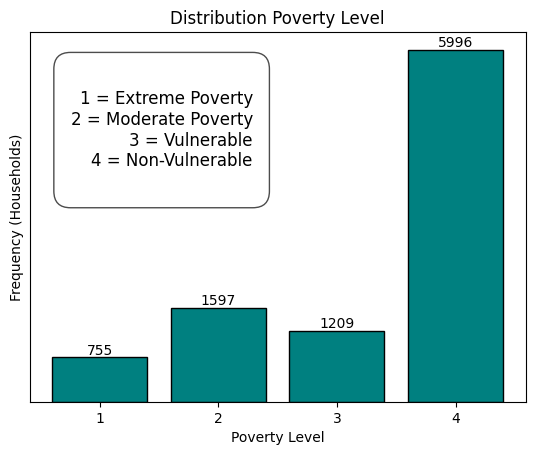

In [ ]:
# Histogram with centered bars

# Define the bins and create custom bin edges
bin_edges = np.arange(int(df['Target'].min()) - 0.5, int(df['Target'].max()) + 1.5, 1)

# Calculate the histogram values
hist_values, _ = np.histogram(df['Target'], bins=bin_edges)

# Calculate the bar positions and adjust for centering on tick marks
bar_positions = bin_edges[:-1] + 0.5  # Shift by 0.5 to center the bars on the tick marks

# Plot the bars manually with spacing (control the width using the `width` parameter)
bar_width = 0.8  # Adjust width to add space between bars
bars = plt.bar(bar_positions, hist_values, width=bar_width, color='teal', edgecolor='black')

# Add the values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.2, int(yval), ha='center', va='bottom', color='black')

# Set the x-axis to increment by 1
plt.xticks(range(int(df['Target'].min()), int(df['Target'].max()) + 1, 1))

# Remove the visible y-axis
plt.yticks([])

# Set labels and title
plt.xlabel('Poverty Level')
plt.ylabel('Frequency (Households)')
plt.title('Distribution Poverty Level')

# Add an info box explaining the values
info_text = '''
1 = Extreme Poverty
2 = Moderate Poverty
3 = Vulnerable
4 = Non-Vulnerable
'''

# Add a text box at the top-right corner of the plot
plt.gca().text(0.45, 0.90, info_text, ha='right', va='top', transform=plt.gca().transAxes,
               fontsize=12, bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=1'))

# Show the plot
plt.show()

# Show the plot
plt.show()

As we can see in our Poverty Level histogram, about 25% of households fall under Extreme Poverty or Moderate Poverty. This tells us that the data is an accurate representation of the 20% to 25% reported by the World Bank Group 2020 Poverty & Equity Brief.

Next, lets take a look at the distribution of age of surveyed individuals.

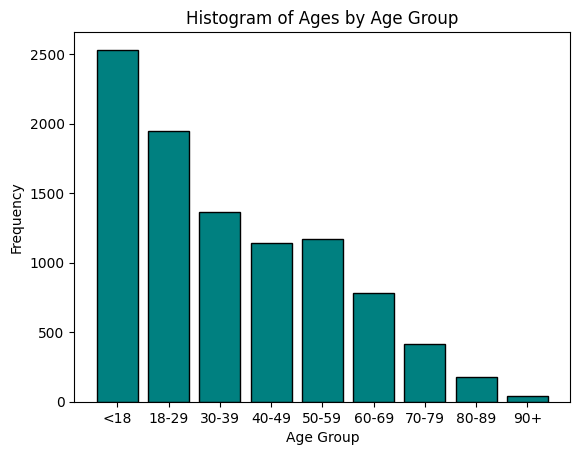

In [ ]:
# Histogram with centered bars for age

# Drop any NaN values in age to avoid errors
ages = df['age'].dropna()

# Define age group buckets
bins = [0, 18, 30, 40, 50, 60, 70, 80, 90, 100]  # Adjust the age ranges as needed
bucket_labels = ['<18','18-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90+']

# Assign each age to a bucket
age_groups = np.digitize(ages, bins)  # Get the index of the bin for each age

# Create the histogram using bucket labels
bucket_counts = [np.sum(age_groups == i) for i in range(1, len(bins))]  # Count occurrences in each bucket

# Plot histogram
plt.bar(bucket_labels, bucket_counts, color='teal', edgecolor='black')

# Add labels and title
plt.xlabel('Age Group')
plt.ylabel('Frequency')
plt.title('Histogram of Ages by Age Group')

# Show plot
plt.show()

It appears that a high percentage of our data comes from those under the age of 18. We will have to think more about this and decide whether we want to include children in the final model. As most forms of assistance will be provided at a household level. It is also not clear if this shows duplicate data. Such as a mother and child both surveyed in the same household.

Next we want to see how the number of children per household relates with poverty level.


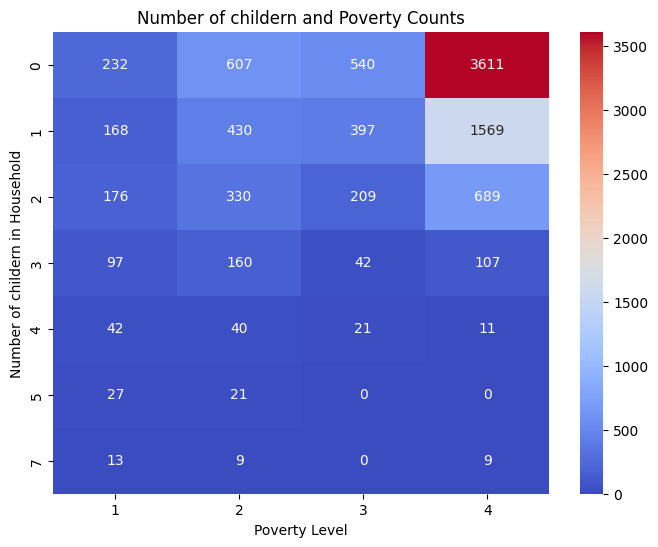

In [ ]:
# Creating a pivot table with counts of each combination of 'r4t1' (number of childern) and 'Target' (poverty level)
# The pivot is needed to aggregate the data in the way we want
pivot_table = pd.pivot_table(df, index='r4t1', columns='Target', aggfunc='size', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='d', cbar=True)

# Add labels and title
plt.title('Number of childern and Poverty Counts')
plt.xlabel('Poverty Level')
plt.ylabel('Number of childern in Household')
plt.show()

Now this was not the best way to look at the data. As we can see, there a far more households without children (the very top right Red box). With such a skewed distribution of the Number of Children, we cannot get a clear look at the relationship this way.

Lets run a correlation on the data instead.

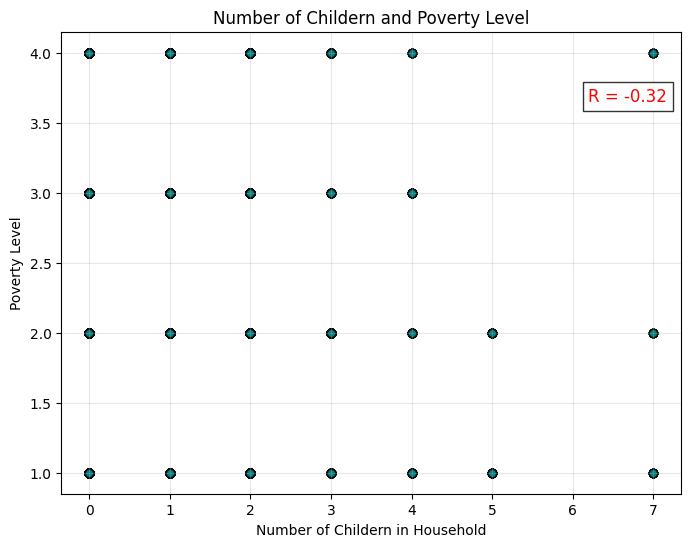

In [ ]:
from scipy.stats import pearsonr

# Calculate the correlation coefficient (R value)
r_value, _ = pearsonr(df['r4t1'], df['Target'])

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['r4t1'], df['Target'], alpha=0.6, color='teal', edgecolor='black')

# Add the R value to the plot
plt.text(0.85, 0.85, f"R = {r_value:.2f}", transform=plt.gca().transAxes,
         fontsize=12, color='red', bbox=dict(facecolor='white', alpha=0.8))

# Add labels and title
plt.title('Number of Childern and Poverty Level')
plt.xlabel('Number of Childern in Household')
plt.ylabel('Poverty Level')
plt.grid(alpha=0.3)
plt.show()

Based on the above scatter and R value, it may be safe to assume that the number of children per household do not effect poverty level (R is less than ABS(0.5)). However, this data set still includes those under the age of 18 who we may exclude in our final analysis.

Given the distribution of households in poverty, right skew towards non-vulnerable families is likely impacting our R value above. We would need to normalize the data to get a better picture of the impact/correlation. We will do this later in the analysis.



We can also look at this another way by comparing the number of children in the household and their Monthly Rent, clustering by Poverty Level (Target).

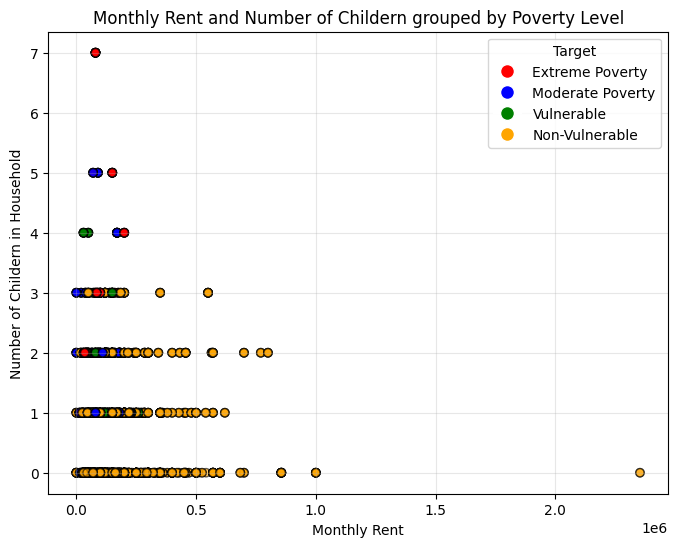

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a colormap for the Target variable
colors = {1: 'red', 2: 'blue', 3: 'green', 4: 'orange'}
color_labels = df['Target'].map(colors)

# Create a scatter plot of Monthly Rent and r4t1, colored by Target
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['v2a1'], df['r4t1'], alpha=0.6, c=color_labels, edgecolor='black')

# Add a custom legend for the Target variable
legend_labels = {1: 'Extreme Poverty', 2: 'Moderate Poverty', 3: 'Vulnerable', 4: 'Non-Vulnerable'}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[key], markersize=10) for key in legend_labels.keys()]
plt.legend(handles, legend_labels.values(), title="Target", loc='upper right', frameon=True)

# Add labels and title
plt.title('Monthly Rent and Number of Childern grouped by Poverty Level')
plt.xlabel('Monthly Rent')
plt.ylabel('Number of Childern in Household')
plt.grid(alpha=0.3)
plt.show()

Let’s take a closer look to see how age correlates with poverty level.
As we can see from the top left red dot, the only family that has 7 children (and low rent/mortgage) is in extreme poverty. However, it is not as clear when looking at the other groups. The overlapping dots make it difficult to gather many insights from this view. The best way that we will be able to take a clear look at the number and children and it's effect on poverty, will be through our classification model later on.

For our last graph, lets look at all other variables and how they correlate to one another (excluding duplicates, explained below).


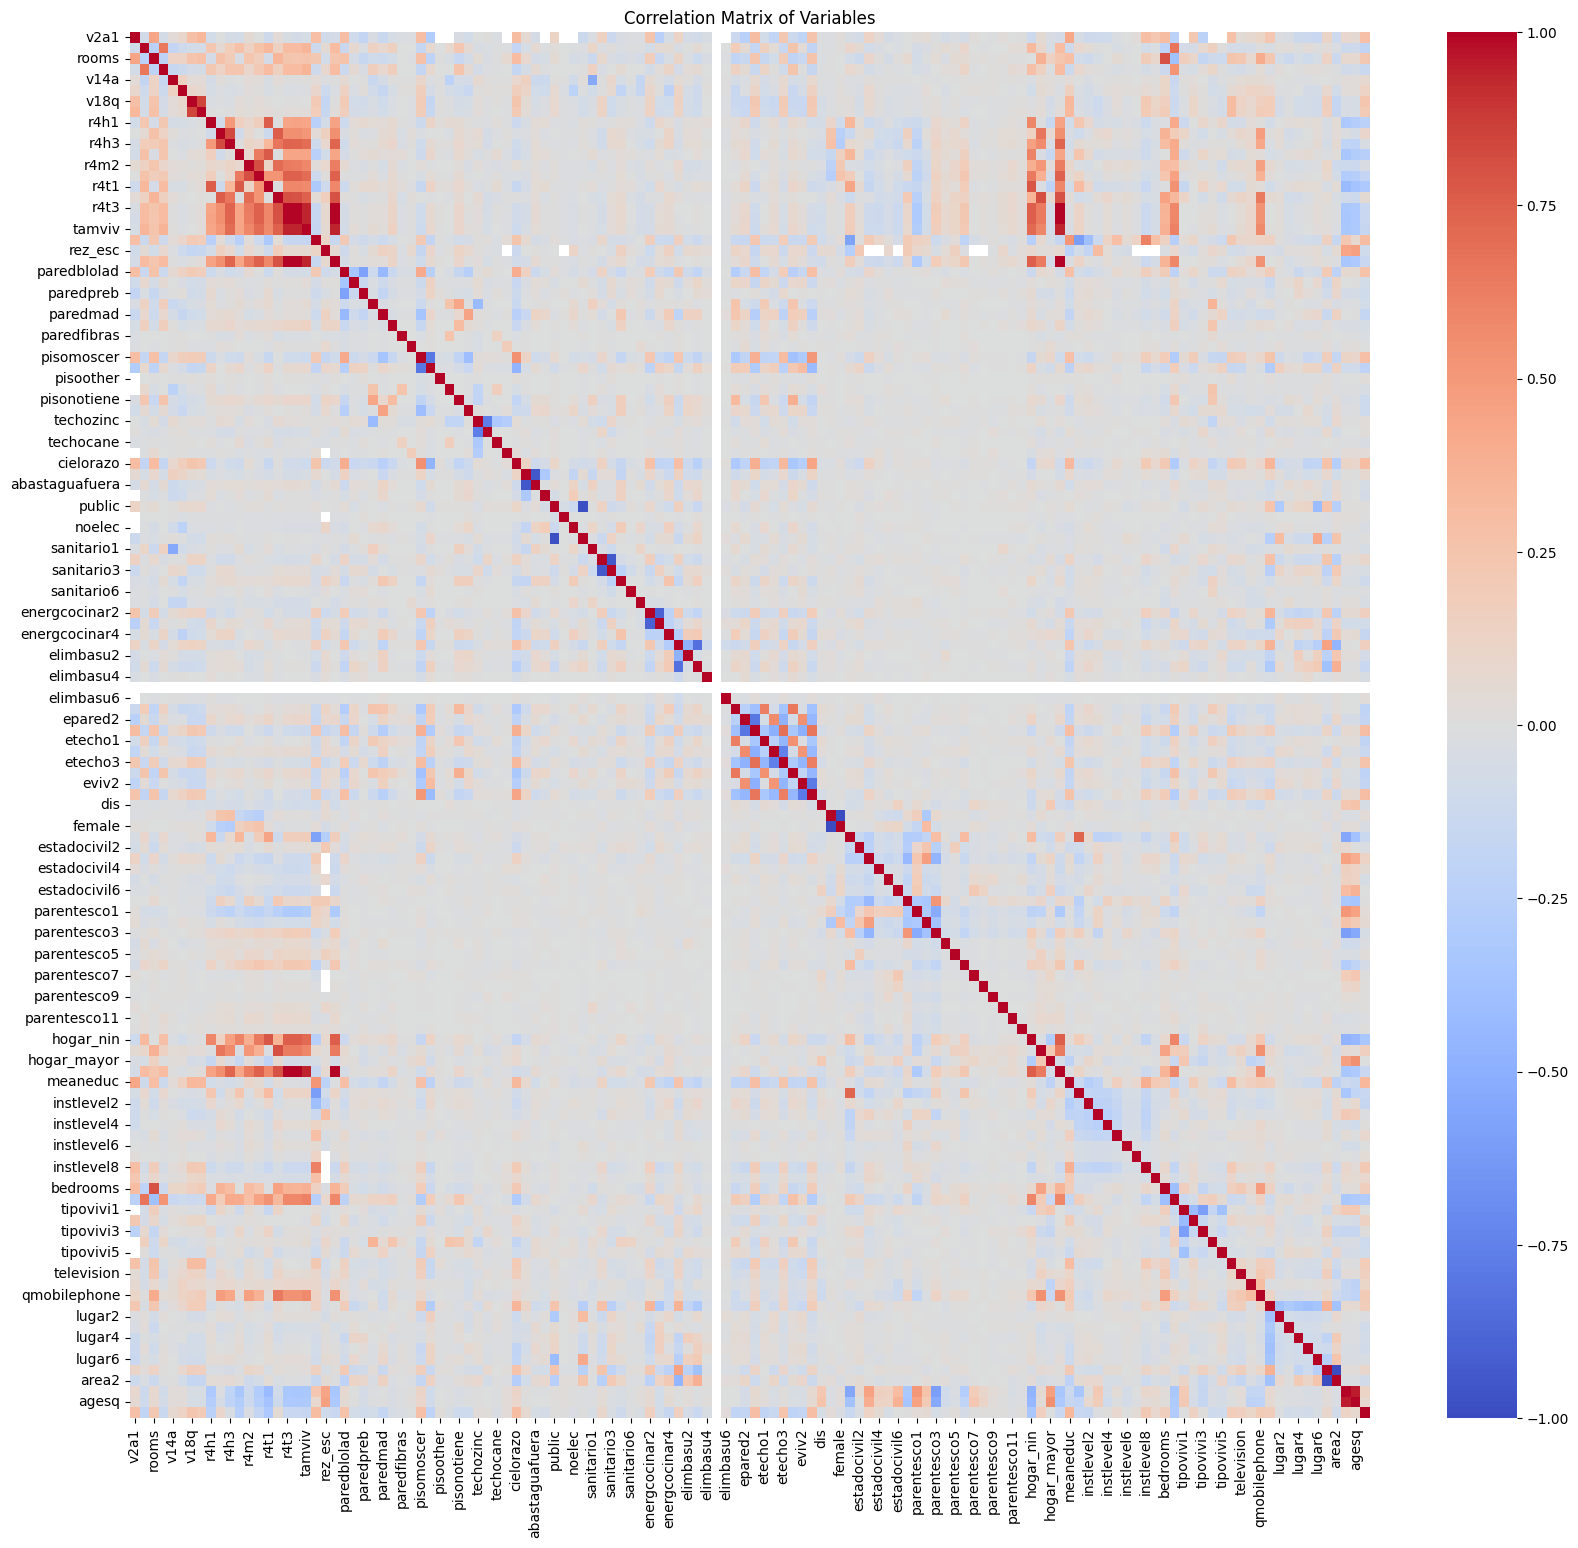

In [ ]:
# Dropping duplicate square root variables first. We are also dropping income ()
variables_to_drop = ['SQBescolari',	'SQBage',	'SQBhogar_total',	'SQBedjefe',	'SQBhogar_nin'	,'SQBovercrowding',	'SQBdependency',	'SQBmeaned']  # Add any columns you want to exclude

# Drop specified variables from the DataFrame
filtered_df = df.drop(columns=variables_to_drop)

# Select only numerical columns for correlation matrix
numerical_df = filtered_df.select_dtypes(include=['number'])

# Compute the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))  # Adjust size as needed
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', cbar=True)

# Add title
plt.title('Correlation Matrix of Variables')
plt.show()

Right off the bat, you can see a cluster of red suqares in the upper left hand corner. Variables starting with "R" corrilcate to other variables starting with "R". If we translate the variable names, these in clude:

*   r4h1 - Males<12
*   r4h2 - Males>=12
*   r4h3 - Males_Total
*   r4m1 - Females<12
*   r4m2 - Females>=12
*   r4m3 - Females_Total
*   r4t1 - persons<12
*   r4t2 - persons>=12
*   r4t3 - Persons_Total

This makes sense why they are corrilated, as the family size, number of males, number of femals, increases togther.

We can also see some other random red squares that indicate stronge relationships (such as meaneduc = average years of education for adults (18+)). But is it difficult to tell what the variables are, as there are so many in this chart. So instead of a chart, we will create a list review each R value.


In [ ]:
# Adjust Pandas display settings to print entire table
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Prevent line breaks
pd.set_option('display.max_colwidth', None)  # Show full column content

# Create correlation matrix
correlation_matrix = numerical_df.corr()

# Convert the correlation matrix to a long-form DataFrame
correlation_list = correlation_matrix.unstack().reset_index()
correlation_list.columns = ['Variable 1', 'Variable 2', 'R Value']

# Remove duplicate and self-correlations
correlation_list = correlation_list[correlation_list['Variable 1'] != correlation_list['Variable 2']]
correlation_list = correlation_list.drop_duplicates(subset=['R Value'])

# Sort by absolute R value in descending order
correlation_list = correlation_list.sort_values(by='R Value', key=abs, ascending=False)

# only show top 15
top_15_correlations = correlation_list.head(15)

# print list
print(top_15_correlations)

            Variable 1      Variable 2   R Value
16376            area1           area2 -1.000000
2231            tamhog          hhsize  1.000000
9564              male          female -1.000000
2097              r4t3          tamhog  0.998107
5767            public         coopele -0.979824
16638              age           agesq  0.958090
5372   abastaguadentro  abastaguafuera -0.946470
2098              r4t3          tamviv  0.945243
2228            tamhog          tamviv  0.943640
2361            tamviv          hhsize  0.943640
6420        sanitario2      sanitario3 -0.939439
7075     energcocinar2   energcocinar3 -0.901042
787               v18q           v18q1  0.849916
7469         elimbasu1       elimbasu3 -0.833666
1180              r4h2            r4h3  0.821367


Now we have a clear list of the top relationships in our data set. We first notice that Poverty Level (Target) is not in this list. But that is okay. We also need to take a look at other relationships in the data because multicollinearity can pose several challenges in our final classification model (such as overfitting and unstable coefficients). We need to be aware of these relationships in order to address them appropriately.

To summarize our initial overview of the data, it is clear that we have some work to do on our data set before we will be ready to predict poverty levels in Costa Rica. We still need to do some data cleaning (variable names, NaN values), variable reduction, and address multicollinearity. However, we also saw promise in our data set by confirming that the data accurately represents the current poverty level and related variables.



-------------------------------------------------------------------------



# Milestone 2
Data Peparation

Now that we have reviewed our data and found some inital relationships and patterens, we want to start drop unessary features, make any needed transformations, deal with missing data, and add any new dummy/useful features to our data set.

Since we noticed many missing values and extra columns in Milestone 1, this will be a good place to start. We will first be removing any columns that are uneeded or cause multicollinearity.

In [ ]:
# print summary
print("Number of columns:", num_columns)
print(f"Total number of rows: {total_rows}")
print(f"Number of rows with blanks: {blank_rows_count}")
print(f"Total number of blank (NaN) values: {total_blank_values}")
print("Column Headers:", column_list)

Number of columns: 143
Total number of rows: 9557
Number of rows with blanks: 9039
Total number of blank (NaN) values: 14798
Column Headers: ['Id', 'v2a1', 'hacdor', 'rooms', 'hacapo', 'v14a', 'refrig', 'v18q', 'v18q1', 'r4h1', 'r4h2', 'r4h3', 'r4m1', 'r4m2', 'r4m3', 'r4t1', 'r4t2', 'r4t3', 'tamhog', 'tamviv', 'escolari', 'rez_esc', 'hhsize', 'paredblolad', 'paredzocalo', 'paredpreb', 'pareddes', 'paredmad', 'paredzinc', 'paredfibras', 'paredother', 'pisomoscer', 'pisocemento', 'pisoother', 'pisonatur', 'pisonotiene', 'pisomadera', 'techozinc', 'techoentrepiso', 'techocane', 'techootro', 'cielorazo', 'abastaguadentro', 'abastaguafuera', 'abastaguano', 'public', 'planpri', 'noelec', 'coopele', 'sanitario1', 'sanitario2', 'sanitario3', 'sanitario5', 'sanitario6', 'energcocinar1', 'energcocinar2', 'energcocinar3', 'energcocinar4', 'elimbasu1', 'elimbasu2', 'elimbasu3', 'elimbasu4', 'elimbasu5', 'elimbasu6', 'epared1', 'epared2', 'epared3', 'etecho1', 'etecho2', 'etecho3', 'eviv1', 'eviv2'

How can we possibly narrow down so many columns when we don't know what they are? We can make this easier on ourselfves by providing a dictionary of exsisting columns and new names. By using dictionary, we ensure the variables are re-named correctly. The new names are made to be a bit more descriptive but still keep the length of the string to a minium.

In [ ]:
# Define the dictionary for renaming columns
rename_dict = {
    'v2a1': 'Monthly_rent',
    'hacdor': 'Overcrowding_bedrooms',
    'rooms': 'rooms_num',
    'hacapo': 'Overcrowding_rooms',
    'v14a': 'toilet',
    'refrig': 'refrigerator',
    'v18q': 'tablet',
    'v18q1': 'tablets_num',
    'r4h1': 'Males<12',
    'r4h2': 'Males>=12',
    'r4h3': 'Males_Total',
    'r4m1': 'Females<12',
    'r4m2': 'Females>=12',
    'r4m3': 'Females_Total',
    'r4t1': 'persons<12',
    'r4t2': 'persons>=12',
    'r4t3': 'Persons_Total',
    'tamhog': 'size of the household',
    'tamviv': 'TamViv',
    'escolari': 'years of schooling',
    'rez_esc': 'Years behind in school',
    'hhsize': 'household size',
    'paredblolad': 'outside wall block or brick',
    'paredzocalo': 'wall_wood_zinc_absbestos',
    'paredpreb': 'wall_prefabricated or cement',
    'pareddes': 'wall_waste_material',
    'paredmad': 'wall_wood ',
    'paredzinc': 'wall_zink',
    'paredfibras': 'wall_natural_fibers',
    'paredother': 'wall_other',
    'pisomoscer': 'floor_mosaic_ceramic_terrazo',
    'pisocemento': 'floor_cement',
    'pisoother': 'floor_other',
    'pisonatur': 'floor_ natural material',
    'pisonotiene': 'floor_none',
    'pisomadera': 'floor_wood',
    'techozinc': 'roof_metal foil or zink',
    'techoentrepiso': 'roof_fibercement_mezzanine ',
    'techocane': 'roof_natural fibers',
    'techootro': 'roof_other',
    'cielorazo': 'ceiling_yes',
    'abastaguadentro': 'water_inside',
    'abastaguafuera': 'water_outside',
    'abastaguano': 'water_none',
    'public': 'electric_cityprovided',
    'planpri': 'electric_privateplant',
    'noelec': 'electric_none',
    'coopele': 'electric_coop',
    'sanitario1': 'toilet_none',
    'sanitario2': 'toilet_sewer',
    'sanitario3': 'toilet_septic',
    'sanitario5': 'toilet_letrine',
    'sanitario6': 'toilet_othersystem',
    'energcocinar1': 'cooking_none',
    'energcocinar2': 'cooking_electricity',
    'energcocinar3': 'cooking_gas',
    'energcocinar4': 'cooking_charcoal',
    'elimbasu1': 'rubbish_truck',
    'elimbasu2': 'rubbish_buried',
    'elimbasu3': 'rubbish_burning',
    'elimbasu4': 'rubbish_unoccupiedspace',
    'elimbasu5': 'rubbish_rivercreeksea',
    'elimbasu6': 'rubbish_other',
    'epared1': 'walls_bad',
    'epared2': 'walls_regular',
    'epared3': 'walls_good',
    'etecho1': 'roof_bad',
    'etecho2': 'roof_regular',
    'etecho3': 'roof_good',
    'eviv1': 'floor_bad',
    'eviv2': 'floor_regular',
    'eviv3': 'floor_good',
    'dis': 'disable_person',
    'male': 'male',
    'female': 'female',
    'estadocivil1': 'less_than_10_years_old',
    'estadocivil2': 'free_or_coupled_uunion',
    'estadocivil3': 'married',
    'estadocivil4': 'divorced',
    'estadocivil5': 'separated',
    'estadocivil6': 'widow_er',
    'estadocivil7': 'single',
    'parentesco1': 'household head',
    'parentesco2': 'spouse_partner',
    'parentesco3': 'son_doughter',
    'parentesco4': 'stepson_doughter',
    'parentesco5': 'son_doughter in law',
    'parentesco6': 'grandson_doughter',
    'parentesco7': 'mother_father',
    'parentesco8': 'father_mother in law',
    'parentesco9': 'brother_sister',
    'parentesco10': 'brother_sister in law',
    'parentesco11': 'other family member',
    'parentesco12': 'other non family member',
    'idhogar': 'Household_identifier',
    'hogar_nin': '#_children_0_to_19',
    'hogar_adul': '#_of_adults',
    'hogar_mayor': '#_of_65_over',
    'hogar_total': '#_total_individuals',
    'dependency': 'Dependency_rate',
    'edjefe': 'years_of_education_of_male_head_of_household',
    'edjefa': 'years_of_education_of_female_head_of_household',
    'meaneduc': 'average_years_of_education_for_adults_(18+)',
    'instlevel1': 'no_level_of_education',
    'instlevel2': 'incomplete_primary',
    'instlevel3': 'complete_primary',
    'instlevel4': 'incomplete_academic_secondary_level',
    'instlevel5': 'complete_academic_secondary_level',
    'instlevel6': 'incomplete_technical_secondary_level',
    'instlevel7': 'complete_technical_secondary_level',
    'instlevel8': 'undergraduate_and_higher_education',
    'instlevel9': 'postgraduate_higher_education',
    'bedrooms': 'number_of_bedrooms',
    'overcrowding': '#_persons_per_room',
    'tipovivi1': 'own_and_fully_paid_house',
    'tipovivi2': 'own,_paying_in_installments',
    'tipovivi3': 'rented',
    'tipovivi4': 'precarious',
    'tipovivi5': 'assigned_borrowed',
    'computer': 'if_the_household_has_notebook_or_desktop_computer',
    'television': 'if_the_household_has_TV',
    'mobilephone': 'if_mobile_phone',
    'qmobilephone': '#_of_mobile_phones',
    'lugar1': 'region_Central',
    'lugar2': 'region_Chorotega',
    'lugar3': 'region_pacifc',
    'lugar4': 'region_Brunca',
    'lugar5': 'region_Huetar_Sount',
    'lugar6': 'region_Huetar_North',
    'area1': 'zona_urbana',
    'area2': '2_rural_zone',
    'age': 'age_in_years',
    'SQBescolari': 'escolari_squared',
    'SQBage': 'age_squared',
    'SQBhogar_total': 'hogar_total_squared',
    'SQBedjefe': 'edjefe_squared',
    'SQBhogar_nin': 'hogar_nin_squared',
    'SQBovercrowding': 'overcrowding_squared',
    'SQBdependency': 'dependency_squared',
    'SQBmeaned': 'meaned_squared',
    'agesq': 'Age_squared'
}

In [ ]:
# Check if df is loaded correctly
df = pd.read_csv('Costa Rican Household Poverty Level.csv')
# Rename the columns using the dictionary
df.rename(columns=rename_dict, inplace=True)

In [ ]:
print(df.columns)

Index(['Id', 'Monthly_rent', 'Overcrowding_bedrooms', 'rooms_num', 'Overcrowding_rooms', 'toilet',
       'refrigerator', 'tablet', 'tablets_num', 'Males<12',
       ...
       'escolari_squared', 'age_squared', 'hogar_total_squared', 'edjefe_squared',
       'hogar_nin_squared', 'overcrowding_squared', 'dependency_squared', 'meaned_squared',
       'Age_squared', 'Target'],
      dtype='object', length=143)


Now that we have the columns renamed in a way that we can understand, lets go through to see what columns are missing more than 40% of their values.

In [ ]:
# Calculate the percentage of missing values per column
missing_percentage = df.isnull().mean()

# Find columns with more than 40% missing values
columns_with_high_missing = missing_percentage[missing_percentage > 0.4].index.tolist()

print("Columns with more than 40% missing values:", columns_with_high_missing)

Columns with more than 40% missing values: ['Monthly_rent', 'Years behind in school']


Since such a high precent of vaules are missing, we want to drop both from our data set.

In [ ]:
# Dropping the ID column
df = df.drop(columns=['Monthly_rent', 'Years behind in school'])

Based on our summary in Milestone 1, we know that the data set has many more missing values. Due to this, we want to fill in the missing with the medium (most occurring) value to ensure we keep the measure but reduce the impact of a null value on our model.

In [ ]:
# Count the total number of missing values in the new Data Frame
total_missing_values = df.isnull().sum().sum()

print("Total number of missing values in the entire Data Frame:", total_missing_values)

Total number of missing values in the entire Data Frame: 10


With only 10 missing values left in our data frame, we can confidently replace these with the medium.

In [ ]:
# Find and select numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Fill missing values in numerical columns with the median of that column
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

In [ ]:
# Re-count the total number of missing values in the new Data Frame
total_missing_values2 = df.isnull().sum().sum()

print("Total number of missing values in the entire Data Frame:", total_missing_values2)

Total number of missing values in the entire Data Frame: 0


Now we have no missing values in our data frame after replacing 10 missing values with the means and removing the variables will over 40% blanks.

Next, we took a look through our variables and descriptions in more detail (outside of Python) and determined that the below, which are duplicates or very closely related (high multicollinearity). This assumption was made for have variable ending in "_squared". These variables already exist (non-squared) and need to be removed.

In [ ]:
# Dropping duplicates or very closly related variables.
df = df.drop(columns=['Id', 'escolari_squared', 'age_squared', 'hogar_total_squared', 'edjefe_squared', 'hogar_nin_squared', 'overcrowding_squared', 'dependency_squared', 'meaned_squared', 'Age_squared'])

Now that we have reduced our variables, we still need to identify other possible multicollinearity. Due to the large number of features, we will create another table to view the top 15 correlations.

In [ ]:
# Adjust Pandas display settings to print entire table
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Prevent line breaks
pd.set_option('display.max_colwidth', None)  # Show full column content

# Select only numerical columns for correlation matrix
numerical_df_2 = df.select_dtypes(include=['number'])

# Create correlation matrix
correlation_matrix = numerical_df_2.corr()

# Convert the correlation matrix to a long-form DataFrame
correlation_list = correlation_matrix.unstack().reset_index()
correlation_list.columns = ['Variable 1', 'Variable 2', 'R Value']

# Remove duplicate and self-correlations
correlation_list = correlation_list[correlation_list['Variable 1'] != correlation_list['Variable 2']]
correlation_list = correlation_list.drop_duplicates(subset=['R Value'])

# Sort by absolute R value in descending order
correlation_list = correlation_list.sort_values(by='R Value', key=abs, ascending=False)

# only show top 15
top_25_correlations = correlation_list.head(25)

# print list
print(top_25_correlations)

                         Variable 1                   Variable 2   R Value
15745                   zona_urbana                 2_rural_zone -1.000000
2051          size of the household               household size  1.000000
9089                           male                       female -1.000000
1921                  Persons_Total        size of the household  0.998107
5379          electric_cityprovided                electric_coop -0.979824
4993                   water_inside                water_outside -0.946470
1922                  Persons_Total                       TamViv  0.945243
2049          size of the household                       TamViv  0.943640
2178                         TamViv               household size  0.943640
6017                   toilet_sewer                toilet_septic -0.939439
6657            cooking_electricity                  cooking_gas -0.901042
641                          tablet                  tablets_num  0.849916
7042                  rub

We can immediately see the top 3 correlations are a problem. They are highly correlated (R=1) meaning that this will cause multicollinearity issues in our model. We know that households living in and urban area ('zona_urbana') are not living in a rural area ('2_rural_zone') so we only need one of these features. This is also true for male and female. The connection between 'size of the household' and 'household size' is simply a duplicate feature. We will remove 'zona_urbana', 'female, and 'size of the household'. Thus removing  multicollinearity but keeping the measure for our model. However, we don't want to stop at correlations with an R value of 1. We need to ensure there are not others that need to be removed.

If we look further down the list, 'Persons_Total' and 'size of the household' is nearly an R of 1 (0.998). Since we also saw 'size of the household' highly correlated to 'household size', it is safe to say that this feature is also a copy of 'household size' and should be removed. We will continue down the list of the top 25 correlations and remove what is needed to further avoid multicollinearity issues that will impact our prediction model.


In [ ]:
# Dropping multicollinearity features
df2 = df.drop(columns=['zona_urbana', 'size of the household', 'Persons_Total', '#_total_individuals', 'TamViv', 'female', 'water_outside', 'tablet', 'Household_identifier'])

Next we want to create new features from our categorical variables (aka, one-hot encoding). Why? Becuase regression models cannot directly handle categorical data due to their inherit design to work with numeric data. One-hot encoding provides a way to represent categories as numbers (0 or 1).

We will find the categorical columns by using the select_dtypes(include=['object']).columns function.

In [ ]:
# Find and select categorical columns
categorical_cols = df2.select_dtypes(include=['object']).columns
categorical_cols_df = df2.select_dtypes(include='object')
categorical_cols_df.head(5)

,Dependency_rate,years_of_education_of_male_head_of_household,years_of_education_of_female_head_of_household
0,no,10,no
1,8,12,no
2,8,no,11
3,yes,11,no
4,yes,11,no


It looks like 'years_of_education_of_female_head_of_household' and years_of_education_of_male_head_of_household are actually continuous variables that have both text and numbers. Where "no" means that there are 0 male/females in the home, so the value should be zero. Meaning that we do not need to create any new variables, but replace all "no"s with 0 for both columns.

In [ ]:
# Convert columns to string type
df2['years_of_education_of_female_head_of_household'] = df2['years_of_education_of_female_head_of_household'].astype(str)
df2['years_of_education_of_male_head_of_household'] = df2['years_of_education_of_male_head_of_household'].astype(str)

# Convert to lowercase and strip whitespace
df2['years_of_education_of_female_head_of_household'] = df2['years_of_education_of_female_head_of_household'].str.lower().str.strip()
df2['years_of_education_of_male_head_of_household'] = df2['years_of_education_of_male_head_of_household'].str.lower().str.strip()

In [ ]:
# Replace 'no' with '0'
df2['years_of_education_of_female_head_of_household'] = df2['years_of_education_of_female_head_of_household'].replace('no', 0)
df2['years_of_education_of_male_head_of_household'] = df2['years_of_education_of_male_head_of_household'].replace('no', 0)

# Replace 'yes' with '1'
df2['years_of_education_of_female_head_of_household'] = df2['years_of_education_of_female_head_of_household'].replace('yes', 1)
df2['years_of_education_of_male_head_of_household'] = df2['years_of_education_of_male_head_of_household'].replace('yes', 1)

'Dependency_rate' is similar in that it is also continuous can contains both text and numbers. Where "no" means that there are no dependents and "yes" means that there is at least 1. To fix this we will replace all "no"s with 0 and "yes"s with 1.

In [ ]:
df2['Dependency_rate'] = df2['Dependency_rate'].replace('no', 0)
df2['Dependency_rate'] = df2['Dependency_rate'].replace('yes', 1)

Since there are no other categorical columns, no new features need to be created.

Now that we have removed un-needed columns, duplicates, multicollinearity, and checked for categorical variables, we can re-insepct our new data frame.

In [ ]:
# inspectremaining columns/variables

# column names list
column_list = df.columns.tolist()

# numbder of columns
num_columns = len(df.columns)

# number of rows observations
total_rows = len(df)
total_rows = df2.shape[0]

# number of blank vaules accross all columns and rows
rows_with_blanks = df2[df.isnull().any(axis=1)]
blank_rows_count = len(rows_with_blanks)

# total number of blank (NaN) values in the entire DataFrame
total_blank_values = df2.isnull().sum().sum()

# print summary
print("Number of columns:", num_columns)
print(f"Total number of rows: {total_rows}")
print(f"Number of rows with blanks: {blank_rows_count}")
print(f"Total number of blank (NaN) values: {total_blank_values}")
print("Column Headers:", column_list)

Number of columns: 131
Total number of rows: 9557
Number of rows with blanks: 0
Total number of blank (NaN) values: 0
Column Headers: ['Overcrowding_bedrooms', 'rooms_num', 'Overcrowding_rooms', 'toilet', 'refrigerator', 'tablet', 'tablets_num', 'Males<12', 'Males>=12', 'Males_Total', 'Females<12', 'Females>=12', 'Females_Total', 'persons<12', 'persons>=12', 'Persons_Total', 'size of the household', 'TamViv', 'years of schooling', 'household size', 'outside wall block or brick', 'wall_wood_zinc_absbestos', 'wall_prefabricated or cement', 'wall_waste_material', 'wall_wood ', 'wall_zink', 'wall_natural_fibers', 'wall_other', 'floor_mosaic_ceramic_terrazo', 'floor_cement', 'floor_other', 'floor_ natural material', 'floor_none', 'floor_wood', 'roof_metal foil or zink', 'roof_fibercement_mezzanine ', 'roof_natural fibers', 'roof_other', 'ceiling_yes', 'water_inside', 'water_outside', 'water_none', 'electric_cityprovided', 'electric_privateplant', 'electric_none', 'electric_coop', 'toilet_no

We have reduced the number of columns from 143 to 131. Number of rows did not need to change (kept all observations). Reduced the number of blanks from 14,798 to zero. These changes were needed and make it possible to move on to step 3 where we will be testing different models and making the final selection for our data set. In the end, our model will be able to predict the poverty level of a home in Costa Rica. Making it easier for public officials to help families in need by making at risk homes (homes that the model determines is extreme poverty(1)) a priority.

# Milestone 3
Model Building and Evaluation

Now that we have our data collected, evaluated/analyzed/understood, cleaned/corrected, and narrowed down, we are ready to start selecting and testing difference machine learning models to help meet our goal. Our goal being a model that can most accurately predict level of poverty (1 through 4) of a home in Costa Rica based off an input of our predictor variables. Enabling public officials to predict which families are in need of support based on inputs such as family size, home size, type of roof, ect. Helping find at risk homes faster.

In order to choose a model, we first identify what type of data we are working with and if we are making a binary prediction (true/false), continues, or ranked.
Since we are looking to predict the poverty level between 1 and 4 (1 being extreme poverty and 4 being not vulnerable) we will need to choose an ordinal model. As the order of our prediction variable is important.

Now this gives us a good selection of models to choose from. Some common models for ordinal data includes Ordinal Regression models (Logistic, Probit),
Tree-Based Models (XGBoost, LightGBM, CatBoost) and Neural Networks. Each model has their own strengths and weaknesses. It is important to understand each, as one may be better at large data sets, one may be easier to interpret (if that is a necessity), or another could be powerful yet requires feature scaling and careful tuning.

After carefully reviewing our data and the strength and weakness of each model for a ordinal classification problem, we selected a Gradient Boosting Model (XGBoost). We chose this model due to it's ability to handle mixed feature types well. As we have a combination of binary and continuous predictor variables.  Gradient Boosting Model are also great a handling non-linear relationships and can be tuned for class imbalance if needed. The down side is that it is not as easier to interpret as say an Ordinal Regression model or Tree-Based. But since we do not need to fully understand the models inner working to achieve our goal of predicting poverty, we will test out our data on the  Gradient Boosting Model first.




In [ ]:
!pip install xgboost

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, cohen_kappa_score
import xgboost as xgb

In [ ]:
# Separating features (X) and target (y)
X = df2.drop('Target', axis=1)  # predicting features
y = df2['Target'] - 1  # target column. XGBoost requires labels to start from 0, so shifting 1-4 to 0-3

# Identify binary and continuous features
binary_features = [col for col in X.columns if X[col].nunique() == 2]  # Binary features (0 or 1)
continuous_features = [col for col in X.columns if col not in binary_features]  # Continuous features

In [ ]:
# processing data for model
# Scale continuous features
scaler = StandardScaler()
X[continuous_features] = scaler.fit_transform(X[continuous_features])

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Before moving forward, we want to check that the class distribution for the target variable is balanced. Meaning that we have a similar number of values for each (1 through 4). This is important for XGBoost and most other models because they are designed to minimize overall error or loss. When classes are imbalanced, the model tends to prioritize the majority class (e.g., likely class 3 (poverty=4) in our case) because it contributes more to the overall loss. This leads to several issues, the main one being a bias toward the majority class. In order to check that the class distribution for the target variable we can use 'normalize=True' on the training set.

In [ ]:
# Checking the class distribution for imbalance
print(y_train.value_counts(normalize=True))

Target
3    0.627338
1    0.167168
2    0.126488
0    0.079006
Name: proportion, dtype: float64


We can see from above that our data set is indeed imbalanced. With 62.7% coming from Class 3 (poverty=4) making up over half of the dataset. This unevenness will create a bias towards poverty 4 levels, meaning that our model will likely classify 'At risk' homes (property 3 and under) as non-risk.

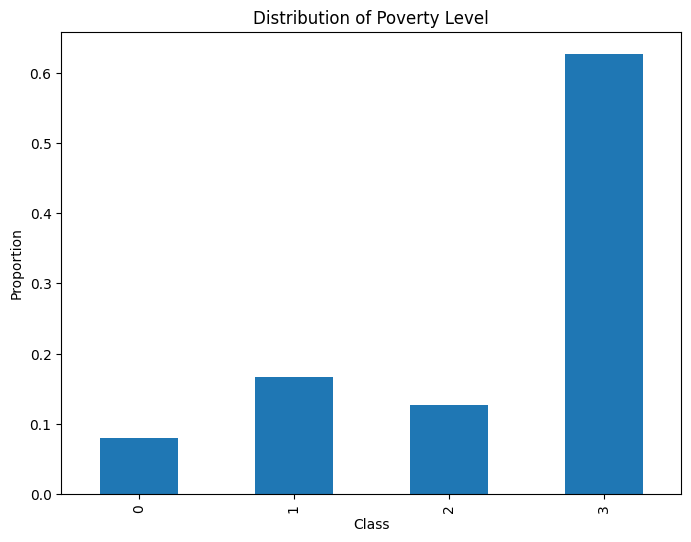

In [ ]:
# Plot class distribution
y_train.value_counts(normalize=True).sort_index().plot(kind='bar', figsize=(8, 6))
plt.title('Distribution of Poverty Level')
plt.xlabel('Class')
plt.ylabel('Proportion')
plt.show()

In order to address this unevenness in target distribution we will use a combination of oversampling and undersampling.

*   Oversampling - Synthetic Minority Over-sampling (SMOTE) to generate synthetic samples for minority classes (Class 0, 1, 2).

*   Undersampling - Reduce the number of samples from the majority class (Class 3) to balance the dataset.

We have chosen this combination method, as the observations that fall under the minority classes (0, 1, 2) are the ones we need to identify and having less of the non-risk class (3) should not impact our project’s goal. We also chose not to go the route of adjusting the model's class weights to penalize misclassifications of minority classes more heavily, as this could be needed later on.


In [ ]:
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=42)
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)

# Check new class distribution
print(pd.Series(y_train_resampled).value_counts(normalize=True))

Target
0    0.276730
2    0.274352
1    0.270523
3    0.178395
Name: proportion, dtype: float64


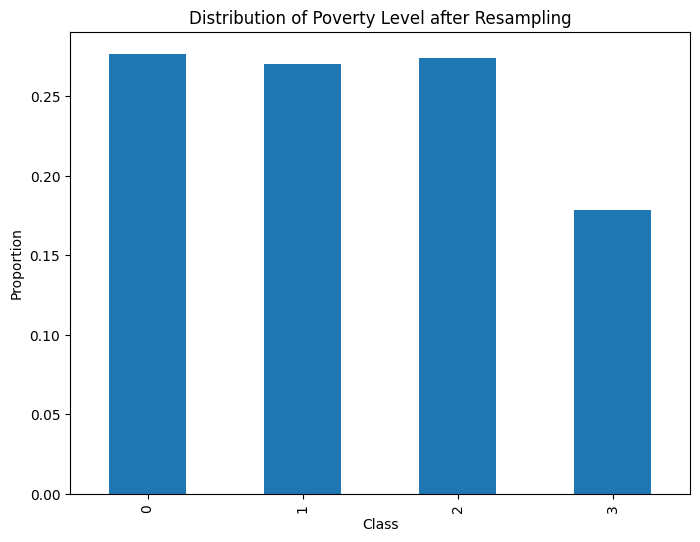

In [ ]:
# Plot class distribution
y_train_resampled.value_counts(normalize=True).sort_index().plot(kind='bar', figsize=(8, 6))
plt.title('Distribution of Poverty Level after Resampling')
plt.xlabel('Class')
plt.ylabel('Proportion')
plt.show()

After a bit of oversampling and under sampling Classes 0, 1, and 2 have similar proportions (~27.7%, 27.1%, and 27.4%), which are relatively balanced.
Class 3 is now underrepresented at 17.8%, but it is closer to the other classes than the original distribution and this class is less important for our use case. Even with the slight unbalanced distribution, this improvement should lead to a well-balanced model.

Before moving forward, lets see how number of children correlate to poverty now that our data is more evenly distributed.

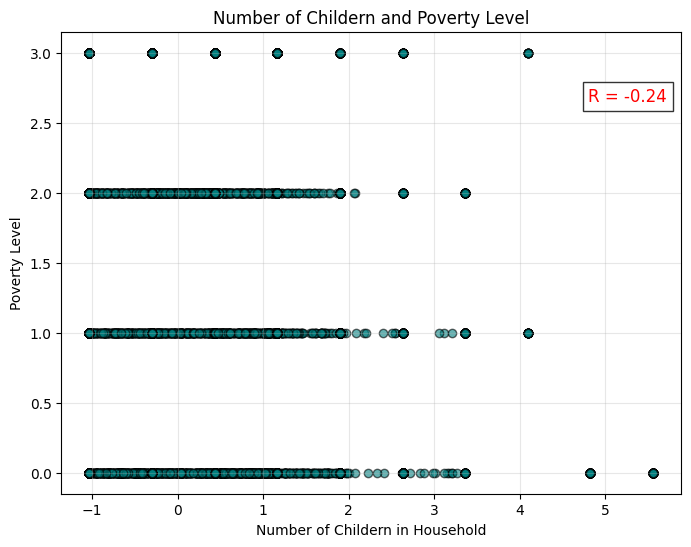

In [ ]:
# Calculate the correlation coefficient (R value)
r_value, _ = pearsonr(X_train_resampled['#_children_0_to_19'], y_train_resampled)

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X_train_resampled['#_children_0_to_19'], y_train_resampled, alpha=0.6, color='teal', edgecolor='black')

# Add the R value to the plot
plt.text(0.85, 0.85, f"R = {r_value:.2f}", transform=plt.gca().transAxes,
         fontsize=12, color='red', bbox=dict(facecolor='white', alpha=0.8))

# Add labels and title
plt.title('Number of Childern and Poverty Level')
plt.xlabel('Number of Childern in Household')
plt.ylabel('Poverty Level')
plt.grid(alpha=0.3)
plt.show()

It appears that even after smoothing out the distribution of poverty levels, the number of children per household makes no significant impact on poverty.

Now before we fit the model, we just need to ensure that feature names do not contain certain special characters like [, ], or < because XGBoost requires feature names to be strings without these characters.

In [ ]:
# Clean feature names by replacing invalid characters (needed for XGBoost)
X_train.columns = X_train.columns.str.replace('[', '', regex=False)
X_train.columns = X_train.columns.str.replace(']', '', regex=False)
X_train.columns = X_train.columns.str.replace('<12', 'young', regex=False)
X_train.columns = X_train.columns.str.replace('>=12', 'old', regex=False)
X_train.columns = X_train.columns.str.replace('<', '', regex=False)
X_train.columns = X_train.columns.str.replace('>', '', regex=False)
X_train.columns = X_train.columns.str.replace(' ', '', regex=False)
X_train.columns = X_train.columns.str.replace('=', '', regex=False)
X_train.columns = X_train.columns.str.replace('#', '', regex=False)
X_train.columns = X_train.columns.str.replace('_', '', regex=False)
X_train.columns = X_train.columns.str.replace('2', '', regex=False)
X_train.columns = X_train.columns.str.replace('(18+)', '', regex=False)
X_train.columns = X_train.columns.str.replace(',', '', regex=False)

# Apply the same cleaning to X_test to ensure consistency
X_test.columns = X_test.columns.str.replace('[', '', regex=False)
X_test.columns = X_test.columns.str.replace(']', '', regex=False)
X_test.columns = X_test.columns.str.replace('<12', 'young', regex=False)
X_test.columns = X_test.columns.str.replace('>=12', 'old', regex=False)
X_test.columns = X_test.columns.str.replace('<', '', regex=False)
X_test.columns = X_test.columns.str.replace('>', '', regex=False)
X_test.columns = X_test.columns.str.replace(' ', '', regex=False)
X_test.columns = X_test.columns.str.replace('=', '', regex=False)
X_test.columns = X_test.columns.str.replace('#', '', regex=False)
X_test.columns = X_test.columns.str.replace('_', '', regex=False)
X_test.columns = X_test.columns.str.replace('2', '', regex=False)
X_test.columns = X_test.columns.str.replace('(18+)', '', regex=False)
X_test.columns = X_test.columns.str.replace(',', '', regex=False)

# Verify the cleaned feature names
print("Cleaned feature names in X_train:")
print(X_train.columns.tolist())

Cleaned feature names in X_train:
['Overcrowdingbedrooms', 'roomsnum', 'Overcrowdingrooms', 'toilet', 'refrigerator', 'tabletsnum', 'Malesyoung', 'Malesold', 'MalesTotal', 'Femalesyoung', 'Femalesold', 'FemalesTotal', 'personsyoung', 'personsold', 'yearsofschooling', 'householdsize', 'outsidewallblockorbrick', 'wallwoodzincabsbestos', 'wallprefabricatedorcement', 'wallwastematerial', 'wallwood', 'wallzink', 'wallnaturalfibers', 'wallother', 'floormosaicceramicterrazo', 'floorcement', 'floorother', 'floornaturalmaterial', 'floornone', 'floorwood', 'roofmetalfoilorzink', 'rooffibercementmezzanine', 'roofnaturalfibers', 'roofother', 'ceilingyes', 'waterinside', 'waternone', 'electriccityprovided', 'electricprivateplant', 'electricnone', 'electriccoop', 'toiletnone', 'toiletsewer', 'toiletseptic', 'toiletletrine', 'toiletothersystem', 'cookingnone', 'cookingelectricity', 'cookinggas', 'cookingcharcoal', 'rubbishtruck', 'rubbishburied', 'rubbishburning', 'rubbishunoccupiedspace', 'rubbishri

Now lets fit our data to the model.

In [ ]:
# fitting XGBClassifier
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=4, num_parallel_tree=None, ...)

In [ ]:
# predict on the test set
y_pred = xgb_model.predict(X_test)

In [ ]:
# Check MAE and QWK
mae = mean_absolute_error(y_test, y_pred)
qwk = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print(f'MAE: {mae:.4f}')
print(f'QWK: {qwk:.4f}')

MAE: 0.1156
QWK: 0.8960


The Mean Absolute Error (MAE) measures the average absolute difference between predicted and true poverty levels. For our ordinal problem with classes 0 to 3 (after shifting from 1-4 to 0-3), MAE ranges from 0 (perfect predictions) to 3 (worst-case predictions), meaning an MAE of 0.1156 is near perfection! The exact meaning is that the model's predictions are off by ~0.12 levels. Indicating that most predictions are either correct or off by only 1 level/class. This is great news and means the model is performing very well in terms of minimizing prediction errors.

The Quadratic Weighted Kappa (QWK) measures agreement between predicted and true classes, with quadratic weighting to penalize larger errors more heavily. It is particularly suitable for ordinal classification because it accounts for the ordered nature of the classes. QWK ranges from -1 (complete disagreement) to 1 (perfect agreement), with 0 indicating random agreement.
Our high result of QWK = 0.8960, indicates a strong agreement between predicted and true poverty levels. According to common guidelines a QWK between 0.81–1.00 is almost perfect.

Overall, the low MAE and high QWK shows us that the model is performing exceptionally well. Let’s take a closer look at Class-Specific Performance.


In [ ]:
# Check Class-Specific Performance
from sklearn.metrics import confusion_matrix

def calculate_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = sum(cm[i, :]) - tp
        fp = sum(cm[:, i]) - tp
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        precision = tp / (tp + fp) if (tp + fp) != 0 else 0

        print(f"Class {i} (Poverty Level {i+1})")
        print(f"- True Positives (TP): {tp}")
        print(f"- False Negatives (FN): {fn}")
        print(f"- Recall: {recall:.4f}")
        print(f"- Precision: {precision:.4f}")
        print()

y_pred = xgb_model.predict(X_test)
calculate_metrics(y_test, y_pred)

Class 0 (Poverty Level 1)
- True Positives (TP): 126
- False Negatives (FN): 25
- Recall: 0.8344
- Precision: 0.9618

Class 1 (Poverty Level 2)
- True Positives (TP): 272
- False Negatives (FN): 47
- Recall: 0.8527
- Precision: 0.8860

Class 2 (Poverty Level 3)
- True Positives (TP): 186
- False Negatives (FN): 56
- Recall: 0.7686
- Precision: 0.9163

Class 3 (Poverty Level 4)
- True Positives (TP): 1181
- False Negatives (FN): 19
- Recall: 0.9842
- Precision: 0.9292



The above chart shows a high recall and precision for all Classes. Class 2 is slightly lower on recall and Class 1 for Precision. Meaning that the model may misclassify Class 2 and 1 some of the time.

Next, we will use 5-fold cross validation along with gridsearch to see if we can improve this metric for Class 1 and 2.

5-fold cross validation will split and resample to train our model on different portions of the training set. GridSearchCV works with 5-fold cross validation by trying several combinations of the values passed in the dictionary and evaluating the best model for each combination using Cross-Validation.

In [ ]:
# Grid Search & 5 fold Cross-Validation

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    error_score='raise'  # raise error if any fit fails
)
# Fit the model
try:
    grid_search.fit(X_train, y_train)
    print(f'Best Parameters: {grid_search.best_params_}')
    print(f'Best MAE: {-grid_search.best_score_:.4f}')
except Exception as e:
    print(f"An error occurred: {e}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best MAE: 0.1203


In [ ]:
# Retrieve the best model
best_model = grid_search.best_estimator_

# Print best model Parameters
print("Best Model Parameters:", best_model.get_params())

Best Model Parameters: {'objective': 'multi:softmax', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'mlogloss', 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.3, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 7, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 1.0, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'num_class': 4}


In [ ]:
# predict with new model
y_pred = best_model.predict(X_test)

In [ ]:
# Check MAE and QWK
mae = mean_absolute_error(y_test, y_pred)
qwk = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print(f'MAE: {mae:.4f}')
print(f'QWK: {qwk:.4f}')

MAE: 0.0842
QWK: 0.9241


The MAE is even lower than before! Going from 0.1156 to 0.0842. The QWK also indicates an improved model with a higher value (0.9241) than before (0.8960).
This improvemnt shows just how much GridSearch and Cross Validation can improve a model.

Let’s take a look at Class-Specific Performance now.

In [ ]:
# Check Class-Specific Performance

def calculate_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = sum(cm[i, :]) - tp
        fp = sum(cm[:, i]) - tp
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        precision = tp / (tp + fp) if (tp + fp) != 0 else 0

        print(f"Class {i} (Poverty Level {i+1})")
        print(f"- True Positives (TP): {tp}")
        print(f"- False Negatives (FN): {fn}")
        print(f"- Recall: {recall:.4f}")
        print(f"- Precision: {precision:.4f}")
        print()

y_pred = xgb_model.predict(X_test)
calculate_metrics(y_test, y_pred)

Class 0 (Poverty Level 1)
- True Positives (TP): 126
- False Negatives (FN): 25
- Recall: 0.8344
- Precision: 0.9618

Class 1 (Poverty Level 2)
- True Positives (TP): 272
- False Negatives (FN): 47
- Recall: 0.8527
- Precision: 0.8860

Class 2 (Poverty Level 3)
- True Positives (TP): 186
- False Negatives (FN): 56
- Recall: 0.7686
- Precision: 0.9163

Class 3 (Poverty Level 4)
- True Positives (TP): 1181
- False Negatives (FN): 19
- Recall: 0.9842
- Precision: 0.9292



Comparing the new model to our first, there is a slight improvement in precision for Class 2, which is positive as it means when the model predicts this class, it's more likely to be correct. However, there is a noticeable decline in recall for Class 1, which might be an issue, as identifying instances at this poverty level (at risk) is critical. Classes 0 and 3 show no change to their previous performance levels.

In summary, the combination of oversampling and undersampling was a necessary step for our model to preform as well as it did even before 5-Fold Cross Validation was applied. The XGBoost model chosen by GridSearchCV performed the best. However, I am still a bit concerned about the decline in recall for Class 1 as it is one of the most important classes for our prediction of poverty in Costa Rica. We will need to continue to review ways to improve this aspect of the model. Possibly by adding weights or trying another model for ordinal classification problems.







Refrences (Milestone 1 & 2 & 3)

United Nations Statistics Division. (2023). The Sustainable Development Goals Report - 2023.(ISBN 978-92-1-101460-0). https://unstats.un.org/sdgs/report/2023/

The White House. (2024, September 10). The 2023 Income, Poverty, and Health Insurance Reports: Strong household income gains, lower official poverty, uninsured rate near record low. https://www.whitehouse.gov/cea/written-materials/2024/09/10/the-2023-income-poverty-and-health-insurance-reports-strong-household-income-gains-lower-official-poverty-uninsured-rate-near-record-low/

Costa rican household poverty dataset. (2021). [Dataset; Csv]. In Kaggle. https://www.kaggle.com/datasets/data855/costa-rican-household-poverty-dataset?select=train.csv

World Bank Group. (2020). Poverty & Equity Brief - Latin America & the Caribbean - Costa Rica. https://databankfiles.worldbank.org/public/ddpext_download/poverty/33EF03BB-9722-4AE2-ABC7-AA2972D68AFE/Global_POVEQ_CRI.pdf
